**K means clustering (find f{x})**

-determine no of clusters by k value

-randomly assign centroids (centroids are cluster center points)

-find distance between centroids and all data points

-associate datapoints closer to nearest centroid

-assign clusters (clusters are set of close and similar data points)

-recalculate centroids for the clusters to find cluster center of the new 
centroid

-cluster points moved from one centroid to another is called inertia
-more cluster points less inertia and vice versa


**Clustering on wheat grain data**

How many clusters of grain?
How to choose a good number of clusters for a dataset using the k-means inertia graph. Dataset contains the measurements of samples of grain.

This dataset was obtained from the [UCI](https://archive.ics.uci.edu/ml/datasets/seeds).

In [39]:
import pandas as pd

seeds_df = pd.read_csv('seeds.csv')
# take out varieties seperately.


In [40]:
seeds_df.head()

,area,perimeter,compactness,length,width,asymmetry_coefficient,groove_length,grain_variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama wheat
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama wheat
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama wheat
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama wheat
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama wheat


In [41]:
seeds_df.describe()

,area,perimeter,compactness,length,width,asymmetry_coefficient,groove_length
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


In [42]:
varieties = list(seeds_df['grain_variety'])

# delete them from original dataset
del seeds_df['grain_variety']

Display the DataFrame to inspect the data.  Notice that there are 7 columns - so each grain sample (row) is a point in 7D space. Scatter plots can't help us here.

In [43]:
seeds_df.head()

,area,perimeter,compactness,length,width,asymmetry_coefficient,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [44]:
#Extract the measurements from the DataFrame using its `.values` attribute:
samples = seeds_df.values

#Measure the quality of clusterings with different numbers of clusters using the inertia.  For each of the given values of `k`, perform the following steps:

  - Create a `KMeans` instance called `model` with `k` clusters.
  - Fit the model to the grain data `samples`.
  - Append the value of the `inertia_` attribute of `model` to the list `inertias`.

In [45]:
from sklearn.cluster import KMeans

ks = range(1, 11)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters=k)

    # Fit model to samples
    model.fit(samples)

    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

In [46]:
inertias

[2719.8524101779526,
 1011.860413284119,
 587.318611594043,
 471.49830938958627,
 398.86298645256016,
 343.80324960354085,
 286.6033339492966,
 266.71121679804025,
 217.1345066871387,
 201.03363623156838]

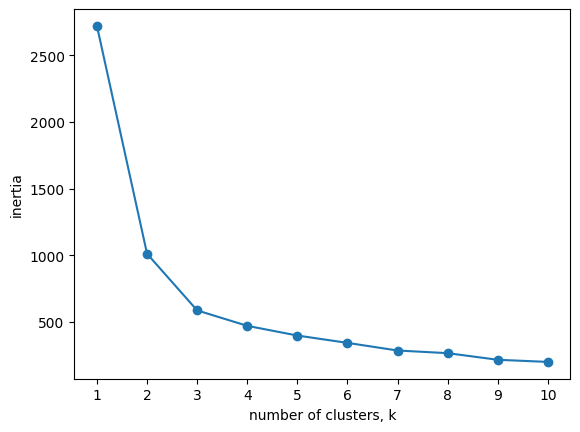

In [47]:
import matplotlib.pyplot as plt

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [48]:
model = KMeans(n_clusters=3)

# Use the .fit_predict() method of model to fit it to samples and derive the cluster labels.

Calling .fit_predict() is the same as calling .fit() and then calling .predict().

In [49]:
labels = model.fit_predict(samples)

In [50]:
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

In [51]:
df.tail()

,labels,varieties
205,0,Canadian wheat
206,0,Canadian wheat
207,0,Canadian wheat
208,0,Canadian wheat
209,0,Canadian wheat


##Use the pd.crosstab() function on df['labels'] and df['varieties'] to count the number of times each grain variety coincides with each cluster label. Assign the result to ct.

In [52]:
ct = pd.crosstab(df['labels'], df['varieties'])

In [53]:
ct

varieties,Canadian wheat,Kama wheat,Rosa wheat
labels,,,
0,68,9,0
1,0,1,60
2,2,60,10


We can see that maximum numbers are concentrated on one or the other clusters. This implies we have acomplished better grouping.

# Clustering Stocks: Which company stock prices tend to move in the same way?
Lets perform K Means Clustering and inspect the cluster labels from the clustering.

In [54]:
import pandas as pd

fn = 'company-stock-movements-2010-2015-incl.csv'
stocks_df = pd.read_csv(fn, index_col=0)

In [55]:
stocks_df.head()

,2010-01-04,2010-01-05,2010-01-06,2010-01-07,2010-01-08,2010-01-11,2010-01-12,2010-01-13,2010-01-14,2010-01-15,...,2013-10-16,2013-10-17,2013-10-18,2013-10-21,2013-10-22,2013-10-23,2013-10-24,2013-10-25,2013-10-28,2013-10-29
Apple,0.580000,-0.220005,-3.409998,-1.170000,1.680011,-2.689994,-1.469994,2.779997,-0.680003,-4.999995,...,0.320008,4.519997,2.899987,9.590019,-6.540016,5.959976,6.910011,-5.359962,0.840019,-19.589981
AIG,-0.640002,-0.650000,-0.210001,-0.420000,0.710001,-0.200001,-1.130001,0.069999,-0.119999,-0.500000,...,0.919998,0.709999,0.119999,-0.480000,0.010002,-0.279998,-0.190003,-0.040001,-0.400002,0.660000
Amazon,-2.350006,1.260009,-2.350006,-2.009995,2.960006,-2.309997,-1.640007,1.209999,-1.790001,-2.039994,...,2.109985,3.699982,9.570008,-3.450013,4.820008,-4.079986,2.579986,4.790009,-1.760009,3.740021
American express,0.109997,0.000000,0.260002,0.720002,0.190003,-0.270001,0.750000,0.300004,0.639999,-0.130001,...,0.680001,2.290001,0.409996,-0.069999,0.100006,0.069999,0.130005,1.849999,0.040001,0.540001
Boeing,0.459999,1.770000,1.549999,2.690003,0.059997,-1.080002,0.360000,0.549999,0.530002,-0.709999,...,1.559997,2.480003,0.019997,-1.220001,0.480003,3.020004,-0.029999,1.940002,1.130005,0.309998


In [56]:
stocks_df.shape

(60, 963)

In [57]:
companies = list(stocks_df.index)
movements = stocks_df.values

from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

normalizer = Normalizer()
kmeans = KMeans(n_clusters=14)
pipeline = make_pipeline(normalizer, kmeans)
pipeline.fit(movements)

Pipeline(steps=[('normalizer', Normalizer()),
                ('kmeans', KMeans(n_clusters=14))])

In [58]:
#Using the `.predict()` method of the pipeline to predict the labels for `movements`
labels = pipeline.predict(movements)


In [59]:
#Align the cluster labels with the list of company names `companies` by creating a DataFrame `df` with `labels` and `companies` as columns.
df = pd.DataFrame({'labels': labels, 'companies': companies})

In [60]:
# Display the DataFrame, sorted by cluster label. Use the `.sort_values()` method of `df` to sort the DataFrame by the `'labels'` column.
df.sort_values('labels')

,labels,companies
10,0,ConocoPhillips
35,0,Navistar
19,1,GlaxoSmithKline
6,1,British American Tobacco
43,1,SAP
42,1,Royal Dutch Shell
37,1,Novartis
46,1,Sanofi-Aventis
49,1,Total
52,1,Unilever
